
**Moeda adotada:** dólar americano (USD), por premissa do projeto baseada no contexto de Seattle. Não houve conversão cambial nem alteração dos valores. A fonte não confirmou explicitamente a moeda. Preços e erros monetários estão em USD; percentuais, R² e contribuições SHAP em log mantêm suas próprias escalas.
# Empacotamento e API — proposta documental

## Objetivo

Descrever como transformar o fluxo validado nos notebooks em um serviço que recebe características de um imóvel e retorna uma estimativa de preço. Esta etapa é somente documentação, conforme o escopo acordado: API, pacote de inferência, Dockerfile e contêiner não foram implementados nem executados.

O modelo e as previsões da etapa 06 já existem. O empacotamento proposto deverá reproduzi-los, sem mudar parâmetros, colunas, regras de transformação ou dados demográficos. A estratégia de operação está no notebook 08 e em [deployment.md](../docs/deployment.md).

**Termos usados:** snapshot é uma cópia fixa dos dados de uma determinada versão; release é uma versão do conjunto entregue; hash/digest é uma identificação calculada a partir do conteúdo para verificar se ele mudou.

## 1. O que existe e o que seria construído

| Componente | Estado atual | Papel na proposta |
|---|---|---|
| `artifacts/modelo_avaliado.joblib` | Gerado no 06 | Preparação aprendida e LightGBM avaliado |
| `artifacts/model_card.json` | Gerado no 06 | Colunas, versões, métricas e referências dos artefatos |
| `artifacts/configuracao_modelo_selecionado.json` | Congelado no 05 | Parâmetros da seleção anterior ao teste |
| `data/processed/contrato_features.json` | Gerado no 03 | Colunas e grupos candidatos |
| `data/raw/zipcode_demographics.csv` | Arquivo fornecido | Tabela demográfica associada ao pacote de inferência |
| `reports/predictions/future_unseen_predictions.csv` | Gerado no 06 | Referência para conferir as previsões após empacotar |
| Pacote Python, API e imagem Docker | Propostos | Executar o fluxo fora dos notebooks |

**Decisão importante:** o joblib recebe **50 colunas já preparadas**. Ele ainda não contém a junção demográfica nem a criação das sete derivadas. Entregar apenas esse arquivo ao consumidor não disponibiliza o fluxo completo. A API proposta receberia as **18 colunas físicas**, fazendo o restante internamente.

## 2. Caminho de uma previsão

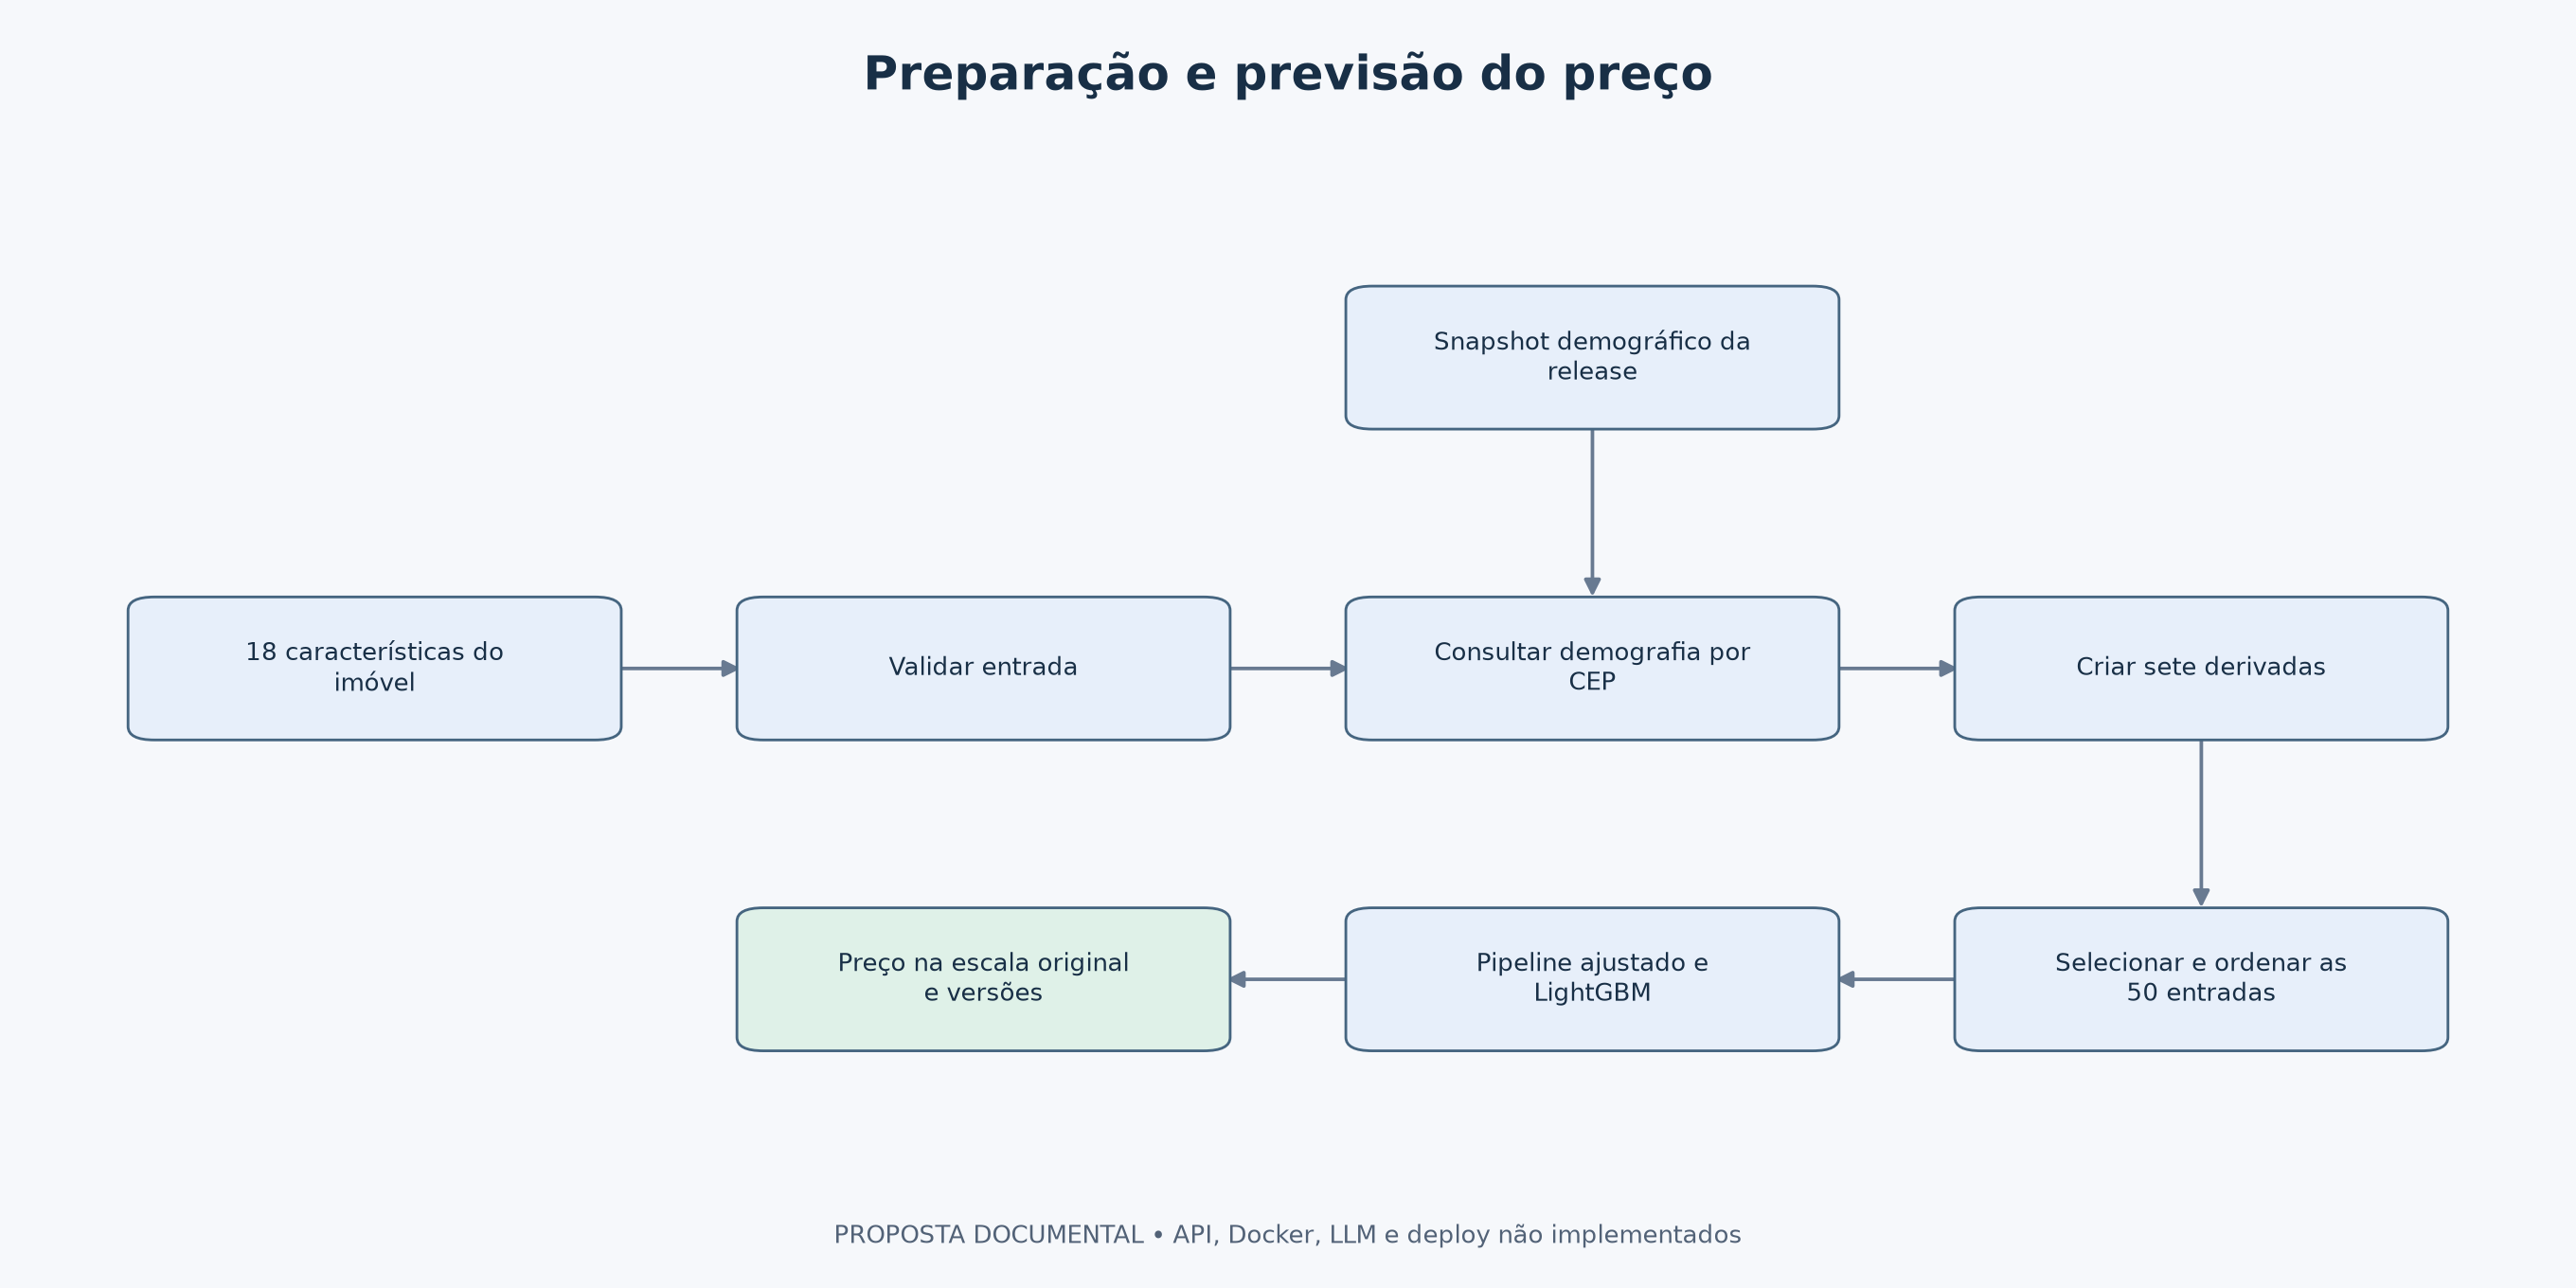

*Esquema da arquitetura proposta; não representa serviços já implantados.*

Leitura do diagrama: validar → enriquecer por CEP → criar derivadas → selecionar as 50 entradas → prever → devolver o preço. O processo serve tanto para uma casa quanto para um lote, mantendo a ordem das linhas.

O pré-processamento ajustado já contém imputação e codificação do CEP. A transformação inversa do preço está no `TransformedTargetRegressor`: a API não deve aplicar `expm1` novamente. Nenhuma mediana, categoria ou estatística seria aprendida a partir da requisição. `price`, `id` e `date` do histórico não seriam entradas preditivas.

## 3. Organização proposta do pacote

Esta árvore é um desenho de organização futura, não uma lista de módulos implementados:

```text
src/house_price/
    schema.py       — contrato e validação
    enrichment.py   — junção demográfica por CEP
    features.py     — sete transformações por linha
    inference.py    — carregamento e previsão compartilhada
    api.py          — endpoints HTTP
tests/              — verificações de integração previstas
release/            — modelo, snapshot, contrato e manifesto
Dockerfile          — receita futura da imagem
.dockerignore       — exclusões do contexto de construção
requirements-runtime.txt — dependências futuras da inferência
```

**Por que separar:** a lógica de previsão ficaria em um único lugar, utilizada pela API e por execução em lote. O código HTTP não repetiria as fórmulas dos notebooks. A extração das funções preservaria as regras existentes; não seria uma nova rodada de feature engineering.

O manifesto de uma release ligaria código, modelo, contrato, snapshot demográfico, dependências e imagem. Nenhum componente deveria ser trocado isoladamente sem verificar compatibilidade. Trocar a demografia também muda as entradas e pode mudar as previsões.

## 4. Contrato de entrada proposto

`POST /predict` receberia uma coleção `instances` de imóveis. Cada item conteria os 18 campos abaixo; a lista manteria a ordem da resposta. Os nomes em inglês preservam o contrato do dataset.

| Campo | Tipo proposto | Regra inicial de validação |
|---|---|---|
| `bedrooms` | Inteiro ou null | Não negativo quando informado |
| `bathrooms` | Número ou null | Não negativo; pode ser fracionário |
| `sqft_living` | Número ou null | Não negativo; zero mantém o tratamento do notebook |
| `sqft_lot` | Número ou null | Não negativo |
| `floors` | Número ou null | Não negativo; pode ser fracionário |
| `waterfront` | Inteiro ou null | 0 ou 1, conforme codificação observada |
| `view` | Inteiro ou null | Categoria presente no contrato; domínio a formalizar com a fonte |
| `condition` | Inteiro ou null | Categoria presente no contrato; domínio a formalizar com a fonte |
| `grade` | Inteiro ou null | Categoria presente no contrato; domínio a formalizar com a fonte |
| `sqft_above` | Número ou null | Não negativo |
| `sqft_basement` | Número ou null | Não negativo |
| `yr_built` | Inteiro ou null | Não negativo; plausibilidade conforme documentação da fonte |
| `yr_renovated` | Inteiro ou null | Não negativo; zero mantém o significado provisório da EDA |
| `zipcode` | Texto obrigatório | Cinco dígitos, preservando zeros à esquerda |
| `lat` | Número ou null | Entre −90 e 90 quando informado |
| `long` | Número ou null | Entre −180 e 180 quando informado |
| `sqft_living15` | Número ou null | Não negativo |
| `sqft_lot15` | Número ou null | Não negativo |

Os campos seriam obrigatórios no esquema, com `null` explícito permitido nos números para distinguir ausência de um campo esquecido. Números não finitos, tipos inválidos e campos extras como `price` seriam rejeitados. Limites estatísticos do histórico não seriam usados para cortar valores automaticamente. Os significados das colunas continuam sujeitos à confirmação da fonte.

**Ausências:** o pipeline consegue preencher números ausentes, mas isso não prova qualidade para um imóvel quase sem informações. Uma política de cobertura mínima precisaria ser definida e validada antes da ativação; o contrato permitiria sinalizar quais campos foram preenchidos. Não inventamos aqui um percentual de ausência aceitável.

**CEP sem cadastro:** a simulação do notebook 02 demonstrou que a junção preserva a linha e gera ausências. Não demonstrou desempenho do modelo nessa situação. A proposta inicial de operação é rejeitar a previsão com mensagem `zipcode_not_supported` até que esse cenário tenha avaliação própria. Para CEP conhecido com indicador ausente, a imputação existente seria mantida e a ocorrência registrada. Essa política HTTP ainda não está implementada.

## 5. Resposta e comportamento dos endpoints

| Endpoint proposto | Finalidade | Resposta prevista |
|---|---|---|
| `POST /predict` | Estimar preços | 200 com lista na ordem recebida |
| `GET /health` | Verificar se o processo responde | 200 enquanto o processo estiver vivo |
| `GET /ready` | Verificar modelo, esquema e snapshot carregados e compatíveis | 200 pronto; 503 indisponível |

Cada resultado incluiria `predicted_price`, `model_version`, `release_version` e avisos de preparação; a resposta incluiria `request_id` e `schema_version`. O identificador da requisição serve para rastreamento, não como feature. `avaliacao_v1` é a versão existente do modelo; uma versão de release do serviço ainda seria criada.

Não devolveríamos “confiança de 90%”, porque não construímos intervalos de previsão calibrados. A resposta indicaria currency = USD e registraria que se trata de uma premissa do projeto, sem conversão cambial. Os números devolvidos seriam estimativas, não preços observados.

| Situação | Tratamento proposto |
|---|---|
| Entrada fora do esquema ou CEP não suportado | 422 com campo e motivo compreensível |
| Um item inválido no lote | Rejeitar o lote inteiro e apontar o índice, sem respostas parciais ambíguas |
| Modelo ou snapshot ausente/incompatível | Prontidão 503 e inferência indisponível |
| Previsão não finita ou não positiva | Erro interno controlado, registro técnico e nenhuma estimativa inválida |
| Falta de autenticação, quando implantada | 401/403 conforme a política de acesso |
| Excesso de requisições ou lote grande | Limites a calibrar; resposta explícita de limite excedido |

FastAPI seria uma opção para implementar o contrato HTTP. O modelo seria carregado uma vez na inicialização, e não a cada pedido. A capacidade de lotes e a concorrência precisariam de medição; não foram medidas na etapa 06.

## 6. Docker: o que seria empacotado e por quê

**Imagem** é o pacote com ambiente, dependências e aplicação; **contêiner** é sua execução. **Dockerfile** é a receita para construir a imagem. O objetivo seria reproduzir a inferência em outro ambiente sem depender de uma sessão aberta de Jupyter.

A receita futura usaria uma base Python compatível com a versão registrada no `model_card.json`, dependências de inferência fixadas, o pacote proposto e os artefatos autorizados. A base seria identificada por versão e digest. O processo executaria sem privilégios de administrador. `.venv`, notebooks, dados de treinamento, credenciais e arquivos desnecessários ficariam fora do contexto da imagem.

**Dependências:** o `requirements.txt` atual reproduz a análise local. Um arquivo menor para inferência seria definido e testado separadamente; não se deve mudar arbitrariamente as versões usadas pelo modelo serializado. Como o experimento foi executado no Windows, a equivalência em um contêiner Linux também precisaria ser verificada, incluindo bibliotecas nativas do LightGBM. Docker não resolve essa compatibilidade automaticamente.

**Decisão de empacotamento:** para esta solução pequena, proponho associar modelo e snapshot à mesma imagem imutável, simplificando a reversão. Isso pressupõe autorização para distribuir esses dados no registro escolhido. Se precisassem ficar externos, seriam baixados na inicialização por identificador fixo e hash, nunca usando silenciosamente a versão “mais recente”.

Uma configuração inicial para testes manteria um processo de API e até duas threads de inferência. Limites de memória, quantidade de réplicas e tamanho de lote seriam dimensionados com teste de carga. Os aproximadamente 239 MiB amostrados na seleção não dimensionam uma API em produção.

**Sequência de implementação futura:** preparar dependências → extrair e verificar o pacote → construir imagem → iniciar contêiner local → conferir prontidão e previsões → testar carga → publicar em homologação. Nenhuma imagem foi construída ou publicada nesta etapa. [Docker: boas práticas](https://docs.docker.com/build/building/best-practices/), [FastAPI em contêineres](https://fastapi.tiangolo.com/deployment/docker/).

## 7. Verificações previstas antes da implantação

| Verificação futura | Evidência esperada |
|---|---|
| Equivalência com o notebook 06 | Mesmas 100 previsões dentro de tolerância numérica de serialização, sem permitir diferença material de preço |
| Casa isolada e lote | Mesma previsão e ordem preservada |
| Contrato de entrada | Tipos inválidos, ausência de campos e preço como entrada rejeitados conforme regra |
| CEP conhecido, desconhecido e indicador ausente | Comportamento conforme a política documentada |
| Artefato trocado ou corrompido | Hash ou versão incompatível impede prontidão |
| Reinício e carga | Tempo de carga, latência, memória e erros registrados |
| Reversão | Conjunto anterior completo continua reproduzindo suas previsões |

As verificações de arquivos e previsões no notebook 06 já foram feitas; verificações de HTTP, Docker e carga **ainda não foram realizadas**. O joblib seria carregado somente de artefatos produzidos e controlados pelo projeto, pois o formato pode executar código ao desserializar. [Persistência de modelos](https://scikit-learn.org/stable/model_persistence.html).

## 8. Observabilidade e limites da proposta

A API proposta registraria identificador, horário, duração, status, versões e ocorrências de ausência ou CEP não suportado. O conteúdo completo dos imóveis não seria gravado por padrão. O detalhe operacional, o feedback de vendas e a substituição do modelo são descritos no notebook 08.

O modelo avaliado teve MAE de 74.089 no teste e maior dificuldade nos imóveis caros. Não há tolerância de negócio aprovada e a disponibilidade histórica da demografia permanece pendente. Empacotar não melhora essas métricas nem torna o modelo automaticamente apto para produção.

## 9. Integração proposta com uma API de LLM

**Motivação:** o objetivo geral do desafio menciona integração entre componentes e APIs de IA. Para contemplar explicitamente esse aspecto, incluí no desenho uma integração com uma API externa de modelo de linguagem (LLM). Ela produziria uma explicação curta da estimativa para o usuário. Esta integração faz parte da proposta documental; nenhum provedor foi conectado, nenhuma chave foi configurada e nenhuma chamada foi executada.

**Responsabilidades:** LightGBM calcula o preço; a LLM redige um texto a partir de informações estruturadas verificadas. O serviço preserva o preço calculado e não aceita que o texto gerado altere esse valor. A explicação não aumenta a precisão do regressor e não demonstra causalidade.

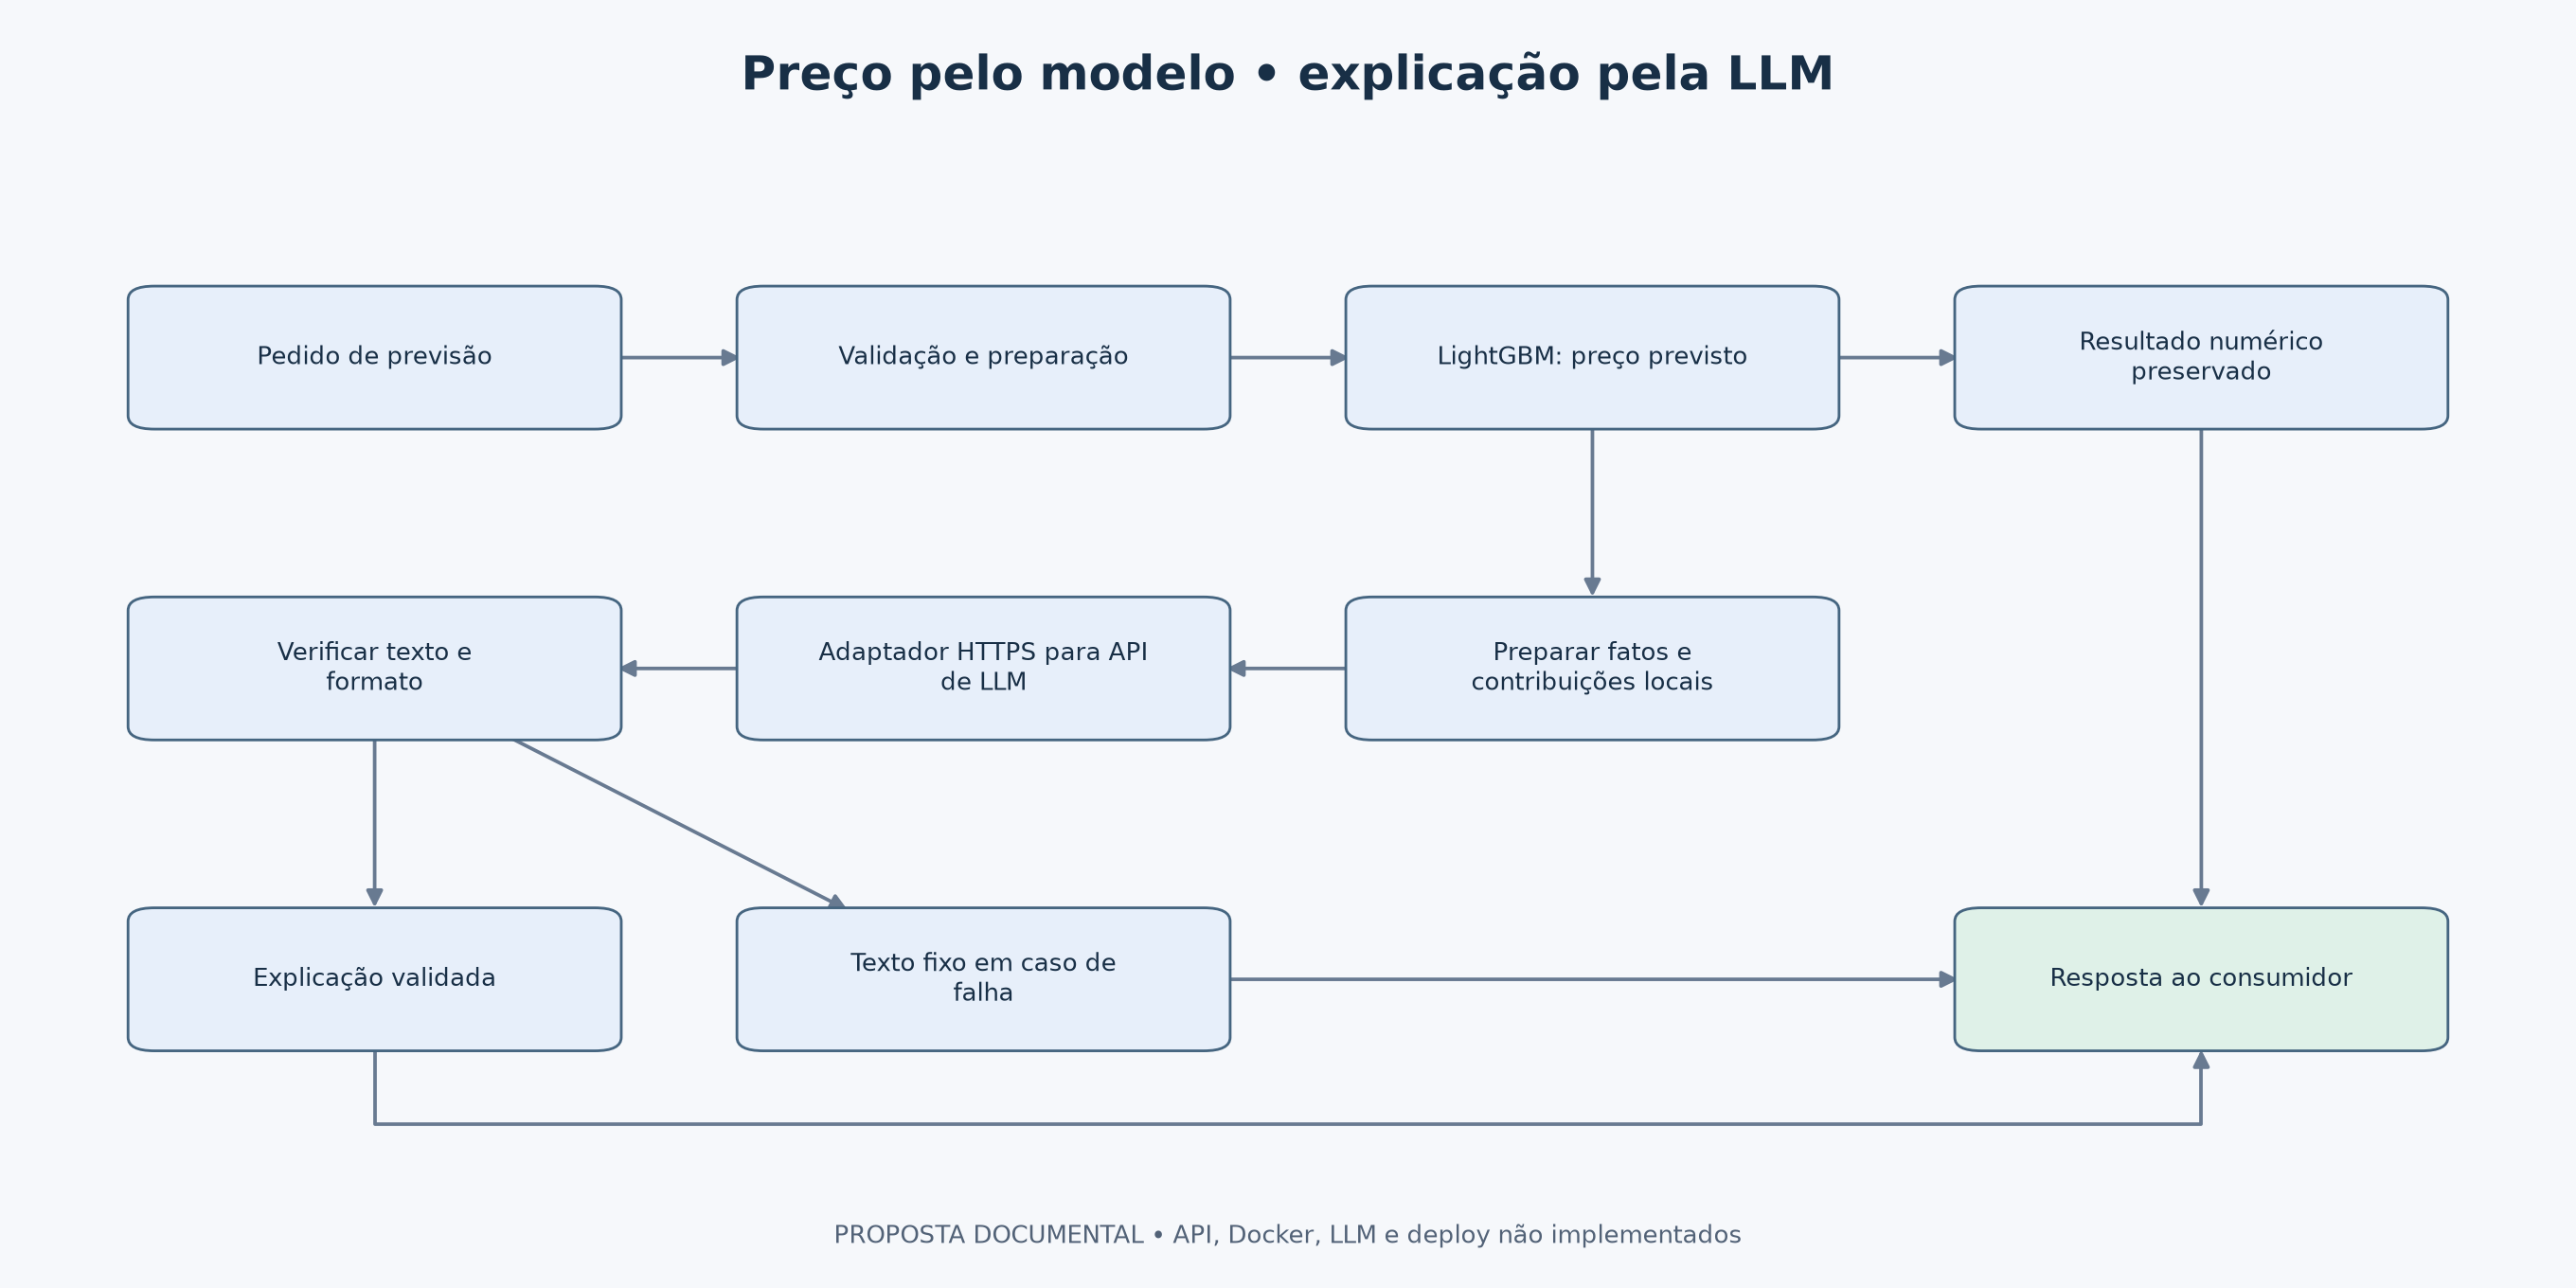

*Esquema da arquitetura proposta; não representa serviços já implantados.*

Leitura: o serviço calcula a previsão e, quando solicitado, monta os fatos para a LLM. O texto passa por verificações antes de ser anexado à resposta. Uma falha na geração não invalida uma previsão numérica que tenha sido concluída corretamente.

### Contrato adicional proposto

O corpo de `POST /predict` poderia incluir `include_explanation`, fora dos itens de `instances`, com valor padrão `false`. Esse controle não é uma feature do imóvel. As 18 entradas físicas continuam sendo as mesmas. A quantidade de explicações por lote teria limite próprio, definido após medir custo e tempo; não faríamos chamadas ilimitadas por padrão.

| Campo adicional da resposta | Finalidade |
|---|---|
| `explanation` | Texto validado ou mensagem fixa de contingência |
| `explanation_status` | `not_requested`, `generated` ou `fallback` |
| `llm_model_version` | Identificador devolvido/registrado para a versão utilizada; null quando não houver geração válida |
| `prompt_version` | Versão das instruções e do formato de contexto |

Esses campos seriam adicionais aos identificadores e ao `predicted_price` calculado pelo serviço. O provedor seria acessado por um adaptador, permitindo mudar a integração sem alterar o pipeline de preços. A escolha do fornecedor dependeria dos requisitos de acesso, tratamento de dados, custo e disponibilidade; nenhum SDK ou formato específico de fornecedor é assumido nesta documentação.

### O que seria enviado à LLM

Somente um contexto autorizado: previsão, nomes e valores necessários das características, principais contribuições locais disponíveis, avisos de preparação e limitações aprovadas. Preço real não é conhecido em uma nova previsão e não seria inventado. O histórico completo, identificadores pessoais, endereço exato e credenciais não seriam enviados. O envio de localização detalhada também dependeria de necessidade e autorização; preferimos um contexto reduzido.

O SHAP global de 600 vendas resume a amostra e não substitui a explicação individual. As três explicações SHAP do notebook 06 pertencem àqueles três imóveis e não podem ser reutilizadas como explicação de outra casa. Para uma nova casa, o serviço precisaria calcular suas contribuições locais ou limitar o texto aos fatos efetivamente disponíveis. O ranking global de permutação não substitui essa explicação individual.

O contexto identificaria as contribuições como valores em **log(1 + preço)**, sem apresentá-las como dinheiro. Se o significado de um indicador não estiver confirmado, a LLM receberia essa limitação; não seria instruída a completar a definição por intuição.

### Exemplo ilustrativo: dos resultados do modelo ao texto

**Exemplo fictício, apenas para explicar o fluxo. O preço e as contribuições abaixo não foram calculados para um imóvel do dataset, e o texto não foi gerado por uma chamada de API.**

**1. O serviço calcula a previsão e prepara os fatos.** Suponha que o LightGBM e a explicação SHAP de uma mesma casa forneçam este contexto:

| Informação enviada à LLM | Conteúdo hipotético |
|---|---|
| Preço previsto pelo LightGBM | 500.000, em USD |
| Área habitável (`sqft_living`) | Contribuição local positiva: elevou a previsão em relação à referência do modelo |
| Localização (`lat`) | Contribuição local positiva |
| Ano de construção (`yr_built`) | Contribuição local negativa |
| Limitação | A estimativa pode diferir do preço de venda; não há intervalo de confiança calculado |

As direções das contribuições seriam obtidas pelo SHAP daquele imóvel. Não seriam deduzidas pela LLM a partir do nome da coluna. Neste exemplo, mostramos apenas a direção, sem atribuir valores monetários às contribuições em log.

**2. A LLM recebe uma instrução de redação**, por exemplo:

> Explique a estimativa em um parágrafo curto, usando somente os fatos fornecidos. Preserve o preço previsto. Descreva as contribuições como comportamento do modelo, sem afirmar causalidade, prometer valorização ou inventar informações de mercado.

**3. Um texto possível para o usuário seria:**

> O preço estimado para este imóvel é de 500 mil. Nesta previsão, a área habitável e a informação de localização contribuíram para elevar a estimativa em relação à referência do modelo. O ano de construção contribuiu para reduzi-la. O valor é uma estimativa e pode diferir do preço efetivo de venda.

**Papel de cada componente no exemplo hipotético:** LightGBM calcularia o preço; SHAP forneceria contribuições locais; a LLM organizaria esses fatos em linguagem simples. Ela não pesquisaria preços de mercado nem calcularia uma nova estimativa. Nenhuma chamada de LLM foi realizada.

Antes de devolver o texto, o serviço verificaria sua consistência com o contexto. Se não houvesse SHAP disponível para a casa, a LLM não deveria afirmar quais características elevaram ou reduziram seu preço: a explicação ficaria limitada à estimativa e às limitações conhecidas.

### Instruções e verificação do texto

As instruções pediriam linguagem simples, concisão e uso exclusivo dos fatos fornecidos, sem prometer valorização, afirmar causalidade ou criar intervalos de confiança. O contexto seria tratado como dado, não como instrução adicional; campos de entrada não poderiam substituir as regras do serviço.

A implementação verificaria formato, presença dos campos esperados e consistência de números mencionados com o contexto. Divergências ou saída inválida levariam ao texto fixo. Essas verificações não garantem a ausência de toda afirmação indevida; uma amostra de textos também precisaria de revisão humana, sobretudo antes de liberar uma nova versão.

**Mensagem de contingência proposta:** “A estimativa foi calculada pelo modelo de preços. A explicação automática está indisponível no momento. Consulte as limitações do modelo.” Isso preserva uma resposta útil sem apresentar uma explicação inventada.

### Falhas, custo e evidências de integração

O adaptador teria tempo máximo de espera, limites de tamanho do contexto e da resposta, orçamento por período e poucas novas tentativas apenas para falhas transitórias. Falha persistente, limite de consumo ou resposta inconsistente acionariam a contingência. Uma previsão válida poderia retornar 200 com `explanation_status = fallback`; erros do próprio cálculo de preço manteriam o tratamento da API descrito anteriormente.

Os testes futuros incluiriam indisponibilidade do provedor, resposta inválida, tentativa de alterar o preço, contribuição ausente, entrada que tenta inserir instruções e lote acima do limite. A evidência esperada é o preço permanecer igual ao resultado sem LLM, com estado da explicação correto. Nada disso foi executado nesta etapa documental.

**Métrica complementar de qualidade:** acompanharíamos também MAPE (%) quando os preços reais estivessem disponíveis, junto de MAE em USD e viés. A referência histórica do LightGBM no teste é 12,77%, sem representar limite de aceitação. Preços reais nulos, negativos ou ausentes seriam sinalizados, sem cálculo silencioso de percentual inválido.
